<a href="https://colab.research.google.com/github/jiyanarikan/Computer-Vision-Covariate-Shift-/blob/main/CompVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from wilds import get_dataset

In [30]:
print("Downloading dataset")

# This downloads to a folder in Colab env
dataset = get_dataset(dataset="poverty", download=True)
train_data = dataset.get_subset("train")
print(f"Total training images loaded: {len(train_data)}")

Total training images loaded: 9797


In [31]:
import torch
import torchvision.models as models
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

In [ ]:
# Load ResNet18 trained on standard images
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)

# Leaves us with a model that outputs a flat vector of numbers
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.eval()

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/CompVision_Poverty_Research'
if not os.path.exists(data_path):
    os.makedirs(data_path)

In [34]:
# Print the field names without loading the whole array into a DF
print("Fields in metadata:", dataset.metadata_fields)

# Pull the metadata for the first 5 samples manually
for i in range(5):
    _, _, meta = train_data[i]
    print(f"Sample {i} metadata: {meta.tolist()}")

Fields in metadata: ['urban', 'y', 'country', 'from_source_domain']
Sample 0 metadata: [0.0, -0.959787368774414, 3.0, 1.0]
Sample 1 metadata: [0.0, -0.859114408493042, 3.0, 1.0]
Sample 2 metadata: [1.0, -0.3560349941253662, 3.0, 1.0]
Sample 3 metadata: [1.0, 1.0717921257019043, 3.0, 1.0]
Sample 4 metadata: [1.0, 0.874895453453064, 3.0, 1.0]


In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

In [36]:
# Filter for 500 Urban (Source) and 500 Rural (Target) samples
metadata = train_data.metadata_array
urban_indices = torch.where(metadata[:, 0] == 1)[0][:500].tolist()
rural_indices = torch.where(metadata[:, 0] == 0)[0][:500].tolist()
subset_indices = urban_indices + rural_indices

In [37]:
loader = DataLoader(torch.utils.data.Subset(train_data, subset_indices), batch_size=32)

all_features = []
all_domains = [] # 1 = Urban, 0 = Rural
all_wealth = []  # Dependent variable (y)

In [ ]:
with torch.no_grad():
    for imgs, labels, metadata in tqdm(loader):
        imgs = imgs[:, :3, :, :].to(device)
        feats = feature_extractor(imgs).view(imgs.size(0), -1)

        all_features.append(feats.cpu().numpy())
        all_domains.append(metadata[:, 0].numpy())
        all_wealth.append(labels.numpy())

In [39]:
X = np.vstack(all_features)
y_domain = np.concatenate(all_domains)
y_wealth = np.concatenate(all_wealth)

print("\nX shape:", X.shape, "| y_domain shape:", y_domain.shape)


X shape: (1000, 512) | y_domain shape: (1000,)


In [40]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split our data into Urban (Source) and Rural (Target)
X_urban = X[y_domain == 1]
y_urban = y_wealth[y_domain == 1]

X_rural = X[y_domain == 0]
y_rural = y_wealth[y_domain == 0]

In [41]:
# Train the Naive Model (Urban only, no weights)
naive_model = Ridge(alpha=1.0)
naive_model.fit(X_urban, y_urban)

Ridge()

In [42]:
# Train the Binary classifier
# This model learns the visual difference between the two environments
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y_domain)

# Probability of being Rural
# probs[:, 0] is the probability the image belongs to the target (Rural) domain
probs = clf.predict_proba(X)
p_rural = probs[:, 0]

# Calculate the IPW Weights for the Urban images
# Weight = P(Target) / P(Source)
# Reweights Urban data to look Rural
weights_all = p_rural / (1 - p_rural + 1e-6)

# Only the weights for the Urban samples (where y_domain == 1)
urban_weights = weights_all[y_domain == 1]

print(f"Number of urban weights: {len(urban_weights)}")

Number of urban weights: 500


In [43]:
# Train the IPW Model (Urban only, WITH our calculated weights)
ipw_model = Ridge(alpha=1.0)
ipw_model.fit(X_urban, y_urban, sample_weight=urban_weights)

Ridge()

In [44]:
# Test both on the rural data
y_pred_naive = naive_model.predict(X_rural)
y_pred_ipw = ipw_model.predict(X_rural)

In [45]:
# Accuracy i.e. R^2 and MSE
mse_naive = mean_squared_error(y_rural, y_pred_naive)
mse_ipw = mean_squared_error(y_rural, y_pred_ipw)

In [46]:
print(f"Results on Rural Data")
print(f"Naive Model MSE: {mse_naive:.4f}")
print(f"IPW-Corrected Model MSE: {mse_ipw:.4f}")
print(f"Error Reduction: {((mse_naive - mse_ipw) / mse_naive)*100:.2f}%")

Results on Rural Data
Naive Model MSE: 0.6117
IPW-Corrected Model MSE: 0.5675
Error Reduction: 7.22%


<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-928/1412899898.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Importance Weight ($\pi(x)$)', fontsize=12)


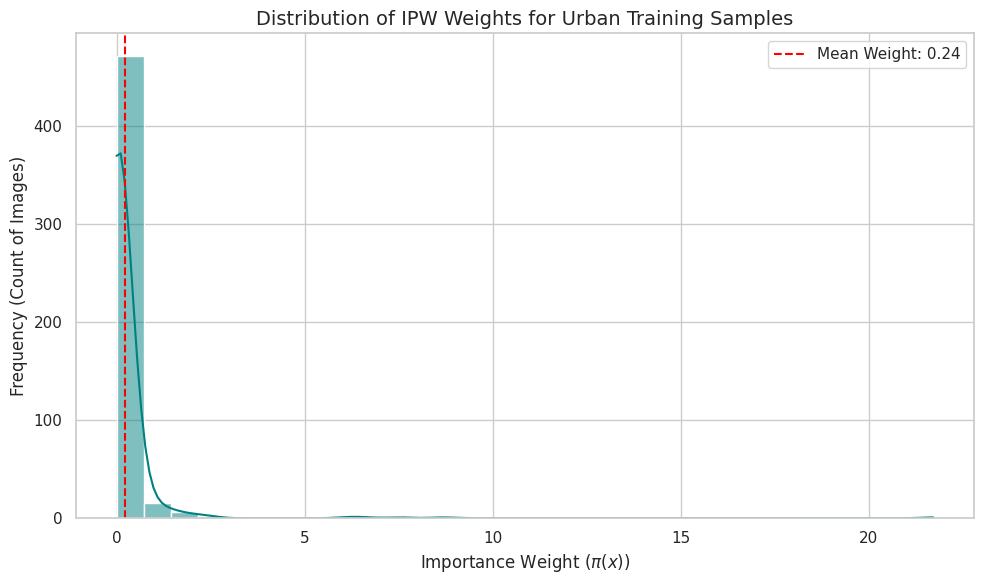

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Distribution of weights for urban images
sns.histplot(urban_weights, bins=30, kde=True, color='teal')

plt.title('Distribution of IPW Weights for Urban Training Samples', fontsize=14)
plt.xlabel('Importance Weight ($\pi(x)$)', fontsize=12)
plt.ylabel('Frequency (Count of Images)', fontsize=12)

# Mean line (red)
plt.axvline(urban_weights.mean(), color='red', linestyle='--', label=f'Mean Weight: {urban_weights.mean():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

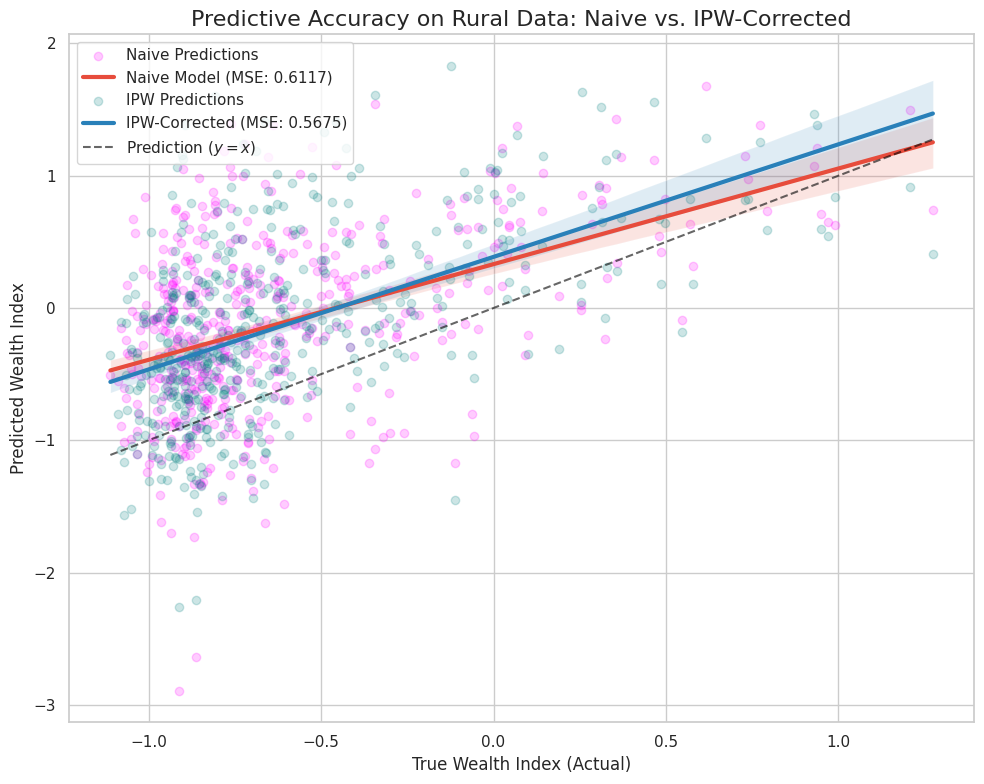

In [48]:
# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# 1. Plot Naive Model Results (Rural Data)
sns.regplot(x=y_rural, y=y_pred_naive,
            scatter_kws={'alpha':0.2, 'color':'fuchsia'},
            line_kws={'color':'#e74c3c', 'linewidth': 3, 'label': f'Naive Model (MSE: {mse_naive:.4f})'},
            label='Naive Predictions')

# 2. Plot IPW-Corrected Model Results (Rural Data)
sns.regplot(x=y_rural, y=y_pred_ipw,
            scatter_kws={'alpha':0.2, 'color':'teal'},
            line_kws={'color':'#2980b9', 'linewidth': 3, 'label': f'IPW-Corrected (MSE: {mse_ipw:.4f})'},
            label='IPW Predictions')

# The Identity Line (y = x)
plt.plot([y_rural.min(), y_rural.max()], [y_rural.min(), y_rural.max()],
         color='black', linestyle='--', alpha=0.6, label='Prediction ($y=x$)')

# Formatting for the paper
plt.title('Predictive Accuracy on Rural Data: Naive vs. IPW-Corrected', fontsize=16)
plt.xlabel('True Wealth Index (Actual)', fontsize=12)
plt.ylabel('Predicted Wealth Index', fontsize=12)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()